# Формула 1

На сайте kaggle есть dataset: https://www.kaggle.com/datasets/muhammadehsan02/formula-1-world-championship-history-1950-2024?resource=download&select=Track_Information.csv

Информация про гонщиков формулы 1. Мне необходимо предсказать кто из пилотов войдет в топ 10.

Целью является предсказать того, попадёт ли пилот в топ-10 по итогам гонки. Модель может использоваться для прогнозирования результатов гонок, анализа эффективности пилотов и команд, а также для поддержки принятия решений в спортивной аналитике.

Данная задача будет решаться в рамках **бинарной классификации**.

In [89]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Импортируем необходимые библиотеки

In [90]:
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

Для удобной работы объединим **4** датасета в один

In [91]:
driver_details = pd.read_csv('/content/Driver_Details.csv')
driver_details.head(5)

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [92]:
qualifying = pd.read_csv('/content/Qualifying_Results.csv')
qualifying.head(5)

,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


In [93]:
race = pd.read_csv('/content/Race_Results.csv')
race.head(5)

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22,1,1,1,1,10.0,58,1:34:50.616,5690616,39,2,1:27.452,218.300,1
1,2,18,2,2,3,5,2,2,2,8.0,58,+5.478,5696094,41,3,1:27.739,217.586,1
2,3,18,3,3,7,7,3,3,3,6.0,58,+8.163,5698779,41,5,1:28.090,216.719,1
3,4,18,4,4,5,11,4,4,4,5.0,58,+17.181,5707797,58,7,1:28.603,215.464,1
4,5,18,5,1,23,3,5,5,5,4.0,58,+18.014,5708630,43,1,1:27.418,218.385,1


In [94]:
team_details = pd.read_csv('/content/Team_Details.csv')
team_details.head(5)


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


Так как основной датасет это race result - начнем объединять с него

In [95]:
data_1 = race.merge(driver_details, how='left', on='driverId')
data_1.head(5)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,fastestLapSpeed,statusId,driverRef,number_y,code,forename,surname,dob,nationality,url
0,1,18,1,1,22,1,1,1,1,10.0,...,218.300,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,18,2,2,3,5,2,2,2,8.0,...,217.586,1,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,18,3,3,7,7,3,3,3,6.0,...,216.719,1,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,18,4,4,5,11,4,4,4,5.0,...,215.464,1,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,18,5,1,23,3,5,5,5,4.0,...,218.385,1,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [96]:
data_2 = data_1.merge(team_details, how='left', on='constructorId')
data_2.head(5)

,resultId,raceId,driverId,constructorId,number_x,grid,position,positionText,positionOrder,points,...,code,forename,surname,dob,nationality_x,url_x,constructorRef,name,nationality_y,url_y
0,1,18,1,1,22,1,1,1,1,10.0,...,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,18,2,2,3,5,2,2,2,8.0,...,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,18,3,3,7,7,3,3,3,6.0,...,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,18,4,4,5,11,4,4,4,5.0,...,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,18,5,1,23,3,5,5,5,4.0,...,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren


Используется объединённый датасет, включающий:

- результаты гонок (Race_Results)
- квалификацию (Qualifying_Results)
- данные о пилотах (Driver_details)
- данные о командах(Team_details)

In [97]:
data = data_2.merge(qualifying, how='left', on=['driverId', 'raceId'])
data.head(5)

,resultId,raceId,driverId,constructorId_x,number_x,grid,position_x,positionText,positionOrder,points,...,name,nationality_y,url_y,qualifyId,constructorId_y,number,position_y,q1,q2,q3
0,1,18,1,1,22,1,1,1,1,10.0,...,McLaren,British,http://en.wikipedia.org/wiki/McLaren,1.0,1.0,22.0,1.0,1:26.572,1:25.187,1:26.714
1,2,18,2,2,3,5,2,2,2,8.0,...,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,5.0,2.0,3.0,5.0,1:25.960,1:25.518,1:27.236
2,3,18,3,3,7,7,3,3,3,6.0,...,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,7.0,3.0,7.0,7.0,1:26.295,1:26.059,1:28.687
3,4,18,4,4,5,11,4,4,4,5.0,...,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,12.0,4.0,5.0,12.0,1:26.907,1:26.188,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,McLaren,British,http://en.wikipedia.org/wiki/McLaren,3.0,1.0,23.0,3.0,1:25.664,1:25.452,1:27.079


In [98]:
#data.to_csv('formula_one.csv', index=False)

# EDA

Переименуем столбцы, которым присвоен x или y

In [99]:
data = data.rename(columns={
    'position_x': 'race_position',
    'position_y': 'quali_position',
    'constructorId_x': 'constructorId_race',
    'constructorId_y': 'constructorId_quali'})

Для начала уберем столбцы связанные с национальнойстью и ссылкой на профиль гонщика, так как смысловой нагрузки в данном анализе не несет.

In [100]:
data.drop(columns=['nationality_x', 'nationality_y', 'url_x', 'url_y'], inplace=True)
data.head(5)

,resultId,raceId,driverId,constructorId_race,number_x,grid,race_position,positionText,positionOrder,points,...,dob,constructorRef,name,qualifyId,constructorId_quali,number,quali_position,q1,q2,q3
0,1,18,1,1,22,1,1,1,1,10.0,...,1985-01-07,mclaren,McLaren,1.0,1.0,22.0,1.0,1:26.572,1:25.187,1:26.714
1,2,18,2,2,3,5,2,2,2,8.0,...,1977-05-10,bmw_sauber,BMW Sauber,5.0,2.0,3.0,5.0,1:25.960,1:25.518,1:27.236
2,3,18,3,3,7,7,3,3,3,6.0,...,1985-06-27,williams,Williams,7.0,3.0,7.0,7.0,1:26.295,1:26.059,1:28.687
3,4,18,4,4,5,11,4,4,4,5.0,...,1981-07-29,renault,Renault,12.0,4.0,5.0,12.0,1:26.907,1:26.188,\N
4,5,18,5,1,23,3,5,5,5,4.0,...,1981-10-19,mclaren,McLaren,3.0,1.0,23.0,3.0,1:25.664,1:25.452,1:27.079


## Общая информация о данных

In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26519 entries, 0 to 26518
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   resultId             26519 non-null  int64  
 1   raceId               26519 non-null  int64  
 2   driverId             26519 non-null  int64  
 3   constructorId_race   26519 non-null  int64  
 4   number_x             26519 non-null  object 
 5   grid                 26519 non-null  int64  
 6   race_position        26519 non-null  object 
 7   positionText         26519 non-null  object 
 8   positionOrder        26519 non-null  int64  
 9   points               26519 non-null  float64
 10  laps                 26519 non-null  int64  
 11  time                 26519 non-null  object 
 12  milliseconds         26519 non-null  object 
 13  fastestLap           26519 non-null  object 
 14  rank                 26519 non-null  object 
 15  fastestLapTime       26519 non-null 

необходимо:
- преобразовать типы данных
- обработки пропущенных значений
- кодирования категориальных признаков

In [102]:
data.describe()

,resultId,raceId,driverId,constructorId_race,grid,positionOrder,points,laps,statusId,qualifyId,constructorId_quali,number,quali_position
count,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,26519.000000,10254.000000,10254.000000,10254.000000,10254.000000
mean,13260.940986,546.376560,274.357291,49.801161,11.145820,12.814812,1.959578,46.228251,17.317056,5141.499415,46.884338,18.526624,11.212112
std,7656.813206,309.642244,279.275606,61.091426,7.213453,7.677869,4.306475,29.577860,26.081700,2976.371659,72.432640,18.243795,6.270548
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,6630.500000,298.000000,57.000000,6.000000,5.000000,6.000000,0.000000,23.000000,1.000000,2565.250000,4.000000,7.000000,6.000000
50%,13260.000000,527.000000,170.000000,25.000000,11.000000,12.000000,0.000000,53.000000,10.000000,5129.500000,9.000000,14.000000,11.000000
75%,19889.500000,803.000000,385.000000,60.000000,17.000000,18.000000,2.000000,66.000000,14.000000,7713.750000,30.000000,22.000000,16.000000
max,26524.000000,1132.000000,860.000000,215.000000,34.000000,39.000000,50.000000,200.000000,141.000000,10311.000000,215.000000,99.000000,28.000000


- Стартовая позиция (grid)  медиана около 11 (всего в сетке 20 пилотов)

- Итоговая позиция (race_position) имеет медиану 7, что близко к границе попадания в топ-10, а разброс значений отражает различие в результатах пилотов.

- Распределение очков (points) показывает, что большинство пилотов не набирают очки (медиана равна 0), однако максимальные значения достигают 50, что соответствует победе в гонке.

- Количество кругов (laps) в среднем составляет около 46, при этом наблюдается значительный разброс, связанный с различиями трасс и сезонов.

- Целевая переменная (top_ten) имеет среднее значение около 0.41 - умеренный баланс классов

### Размер датасете

In [103]:
data.shape

(26519, 33)

26519 - строки
34 - столбцы

## Анализ целевой переменной и выбор метрики

In [104]:
data['race_position'] = pd.to_numeric(data['race_position'], errors='coerce')
data['top_ten'] = (data['race_position'] <= 10).astype(int)
data['top_ten'].value_counts(normalize=True)

,proportion
top_ten,
0,0.590407
1,0.409593


В качестве основной метрики я выбрала F1-score.

Данные в целом сбалансировано(распределение целевой переменной показывает умеренный дисбаланс классов примерно 60% и 40%). F1 учитывает баланс между precision и recall и позволит более корректно оценивать качество классификации.

Я бы дополнительно использовала метрику ROC-AUC для оценки способности модели различать классы.

<Axes: xlabel='top_ten', ylabel='count'>

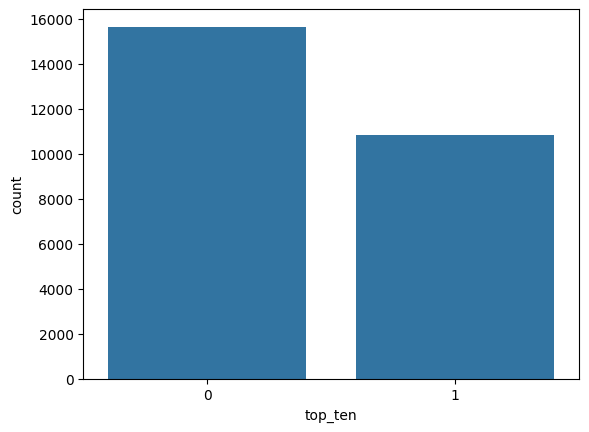

In [105]:
sns.countplot(x='top_ten', data=data)

Я проанализировала распределение целевой переменной топ 10 - классы распределены неравномерно: доля пилотов, не попадающих в топ-10, составляет около 60%, тогда как доля пилотов, попадающих в топ-10, — около 40%.

Такое распределение показывает умеренный дисбаланс классов.

## Анализ ключевых признаков

<Axes: xlabel='top_ten', ylabel='grid'>

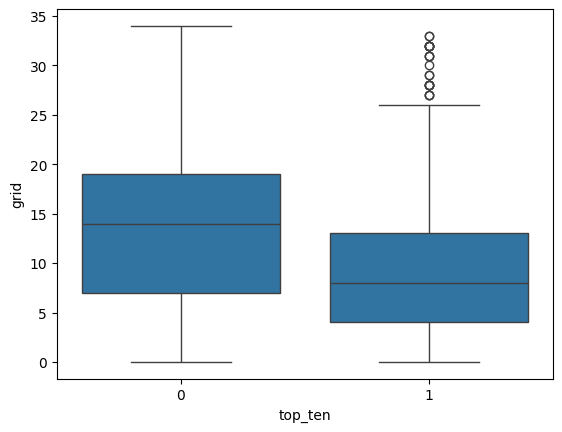

In [106]:
sns.boxplot(x='top_ten', y='grid', data=data)

Я заметила, что пилоты, стартующие с более высоких позиций, значительно чаще попадают в топ-10. Это объясняется тем, что в Formula 1 стартовая позиция оказывает существенное влияние на итоговый результат гонки.

Пилоты, находящиеся впереди, получают преимущество в виде «чистой» трассы, что позволяет им ехать в оптимальном темпе без потери времени за более медленными машинами. Кроме того, они реже попадают в инциденты на старте и в первых поворотах, где риск столкновений особенно высок.

Также важную роль играет стратегия: пилоты с хорошей стартовой позицией имеют больше возможностей контролировать гонку, выбирать оптимальные моменты для пит-стопов и избегать трафика -> напрямую влияет на итоговую позицию.

В то же время пилоты, стартующие с низких позиций, вынуждены активно обгонять, что связано с повышенным риском и потерей времени. Даже при высокой скорости машины это значительно снижает вероятность попадания в топ-10.

Когда пилоты с низких позиций достигают высоких результатов. Это может быть связано с нестандартными стратегиями, сходами соперников, погодными условиями или появлением машины безопасности, которые способны существенно изменить ход гонки.

<Axes: xlabel='grid', ylabel='Count'>

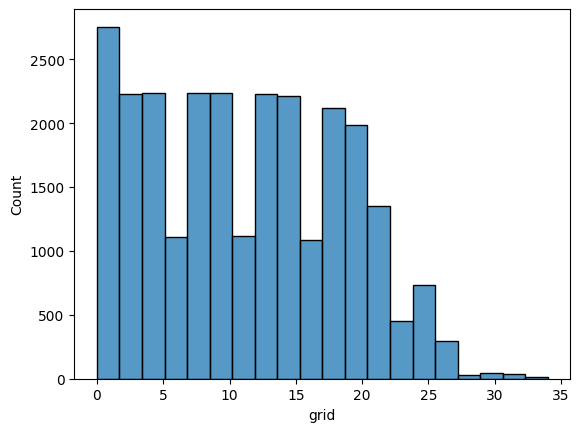

In [107]:
sns.histplot(data['grid'], bins=20)

Распределение признака grid является достаточно равномерным и не содержит выраженных аномалий.
Пилотов на старте 20 человек, поэтому распределение в равной степени соответствует от о до 20

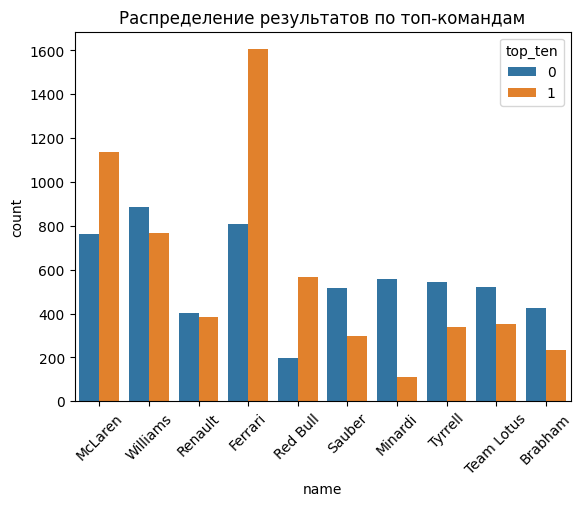

In [108]:
top_teams = data['name'].value_counts().head(10).index

sns.countplot(
    data=data[data['name'].isin(top_teams)],
    x='name',
    hue='top_ten'
)

plt.xticks(rotation=45)
plt.title('Распределение результатов по топ-командам')
plt.show()

У некоторых команд, таких как Ferrari и McLaren, количество попаданий в топ-10 значительно превышает количество случаев, когда пилоты не попадают в топ-10.

В Minardi или Sauber, наблюдается обратная ситуация: пилоты значительно чаще остаются вне топ-10.

Также можно увидеть, что даже среди топ-команд существует различие в результатах, что может быть связано с изменением их конкурентоспособности в разные сезоны.


***Ferrari болид***


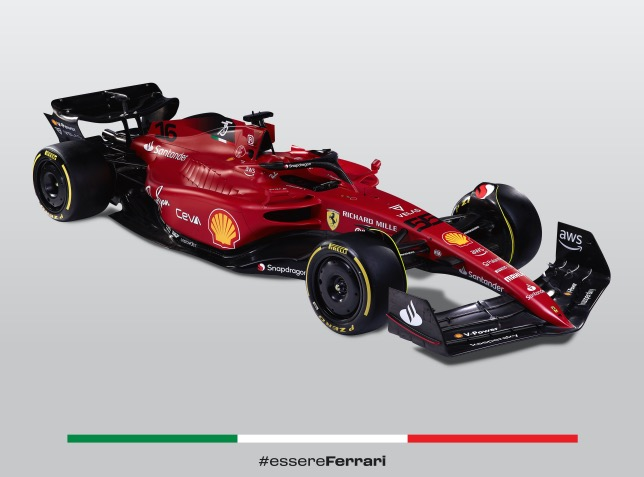

## Анализ пропусков

In [109]:
data.isna().sum().sort_values(ascending=False)

,0
q3,16292
q2,16278
qualifyId,16265
constructorId_quali,16265
q1,16265
quali_position,16265
number,16265
race_position,10928
raceId,0
resultId,0


q1, q2, q3 и др.- это этапы квалификации, которые определяют с какой позиции гогщики наичнают стартоват. Пропуски могут быть связаны с тем, что не все пилоты участвуют во всех этапах квалификации (например, выбывают на ранних стадиях), либо с отсутствием данных в отдельных сезонах.

Также присутствуют пропуски в признаке race_position, что может быть связано с тем, что некоторые пилоты не завершили гонку (сходы, технические проблемы и тд)

***Делаем выводы:***

Стартовая позиция влияет на то попадет пилот в топ 10 или нет.

Пилоты, стартующие с более высоких позиций, значительно чаще достигают высоких результатов, что подтверждается распределением признака grid.

Команды существенно различаются по количеству попаданий в топ-10, что указывает на важность технических характеристик болида.

В данных присутствуют пропуски, особенно в признаках, связанных с квалификацией и  требуют доп обработки.

